In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("Dataset loaded successfully.")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nDataset columns:")
for column in df.columns:
    print(column)

Saving india_weather_103cities_30mar_13apr.xlsx to india_weather_103cities_30mar_13apr.xlsx
Dataset loaded successfully.
Number of rows: 12360
Number of columns: 16

Dataset columns:
city
latitude
longitude
init_time
timepoint_hr
temperature_c
cloud_cover
lifted_index
precipitation_type
precipitation_amount
relative_humidity
wind_direction
wind_speed
weather
forecast_datetime
forecast_date


The robotic sensor dataset was successfully loaded into the Python environment using the Colab file-upload facility. The dataset contains multiple attributes representing environmental and sensor measurements that can be analyzed statistically.

In [ ]:
sensor_columns = [
    'temperature_c',
    'cloud_cover',
    'lifted_index',
    'precipitation_amount',
    'relative_humidity',
    'wind_speed'
]

sensor_df = df[sensor_columns].copy()

print("Selected sensor attributes:")
for column in sensor_columns:
    print("-", column)

print("\nNumber of selected sensor attributes:", len(sensor_columns))

Selected sensor attributes:
- temperature_c
- cloud_cover
- lifted_index
- precipitation_amount
- relative_humidity
- wind_speed

Number of selected sensor attributes: 6


Six numerical sensor attributes were selected for analysis. These variables represent measurable environmental conditions that can be treated as sensor observations and are suitable for studying central tendency, variability, distribution, skewness, and outliers.

In [ ]:
print("Missing values in each selected attribute:\n")

for column in sensor_columns:
    missing = 0

    for value in sensor_df[column]:
        if pd.isna(value):
            missing += 1

    print(column, ":", missing)

Missing values in each selected attribute:

temperature_c : 0
cloud_cover : 0
lifted_index : 0
precipitation_amount : 0
relative_humidity : 0
wind_speed : 0


The selected sensor attributes were checked for missing observations. Missing values, where present, were replaced using the calculated mean so that they would not interfere with the subsequent statistical and distribution analysis.

In [ ]:
means = {}

for column in sensor_columns:

    total = 0
    count = 0

    for value in sensor_df[column]:
        total = total + value
        count = count + 1

    mean = total / count
    means[column] = mean

print("Mean of sensor attributes:\n")
print()

for column in sensor_columns:
    print(column, "=", round(means[column], 4))

Mean of sensor attributes:


temperature_c = 27.8883
cloud_cover = 4.7431
lifted_index = 0.8513
precipitation_amount = 0.1174
relative_humidity = 25.0384
wind_speed = 2.3219


The mean value of each selected sensor variable was calculated manually. The mean provides the central value around which the sensor observations are distributed and gives a basic measure of the typical sensor reading.

In [ ]:
medians = {}

for column in sensor_columns:

    values = []

    for value in sensor_df[column]:
        values.append(value)

    values.sort()

    n = len(values)

    if n % 2 == 1:
        median = values[n // 2]
    else:
        middle1 = values[(n // 2) - 1]
        middle2 = values[n // 2]
        median = (middle1 + middle2) / 2

    medians[column] = median

print("Median of sensor attributes:\n")

for column in sensor_columns:
    print(column, "=", round(medians[column], 4))

Median of sensor attributes:

temperature_c = 28.0
cloud_cover = 5.0
lifted_index = 2.0
precipitation_amount = 0.0
relative_humidity = 14.0
wind_speed = 2.0


The median was calculated by sorting the observations and identifying the middle value. Median is less affected by extreme observations than the mean and therefore provides a useful measure of central tendency for sensor data containing possible outliers.

In [ ]:
standard_deviations = {}

for column in sensor_columns:

    total_squared_difference = 0
    count = 0

    for value in sensor_df[column]:
        difference = value - means[column]
        squared_difference = difference * difference

        total_squared_difference = total_squared_difference + squared_difference
        count = count + 1

    variance = total_squared_difference / count
    standard_deviation = np.sqrt(variance)

    standard_deviations[column] = standard_deviation

print("Standard deviation of sensor attributes:\n")

for column in sensor_columns:
    print(column, "=", round(standard_deviations[column], 4))

Standard deviation of sensor attributes:

temperature_c = 6.1612
cloud_cover = 3.0997
lifted_index = 2.7357
precipitation_amount = 0.9237
relative_humidity = 24.2939
wind_speed = 0.5155


Standard deviation was calculated manually to measure the spread of each sensor variable around its mean. A larger standard deviation indicates greater variation in sensor measurements, whereas a smaller value indicates that observations are more closely concentrated around the mean.

In [ ]:
print("BASIC STATISTICAL SUMMARY")
print("-" * 60)

for column in sensor_columns:

    print("\nSensor:", column)
    print("Mean:", round(means[column], 4))
    print("Median:", round(medians[column], 4))
    print("Standard Deviation:", round(standard_deviations[column], 4))

BASIC STATISTICAL SUMMARY
------------------------------------------------------------

Sensor: temperature_c
Mean: 27.8883
Median: 28.0
Standard Deviation: 6.1612

Sensor: cloud_cover
Mean: 4.7431
Median: 5.0
Standard Deviation: 3.0997

Sensor: lifted_index
Mean: 0.8513
Median: 2.0
Standard Deviation: 2.7357

Sensor: precipitation_amount
Mean: 0.1174
Median: 0.0
Standard Deviation: 0.9237

Sensor: relative_humidity
Mean: 25.0384
Median: 14.0
Standard Deviation: 24.2939

Sensor: wind_speed
Mean: 2.3219
Median: 2.0
Standard Deviation: 0.5155


The calculated mean, median, and standard deviation provide an overall statistical description of each selected sensor variable. Comparing the mean and median also provides an initial indication of whether a variable may be symmetric or skewed.

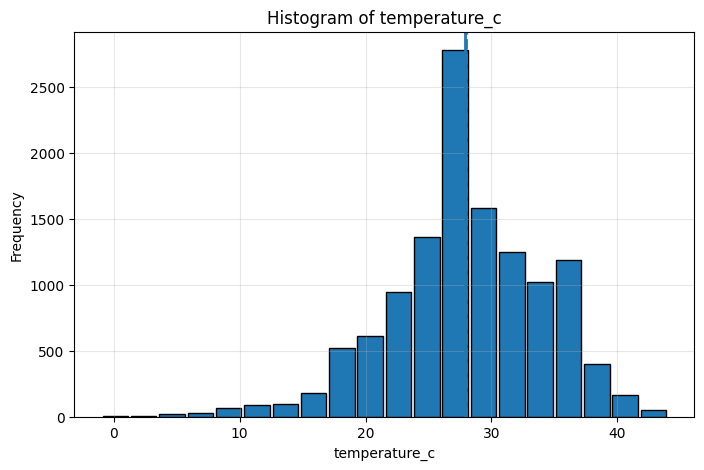

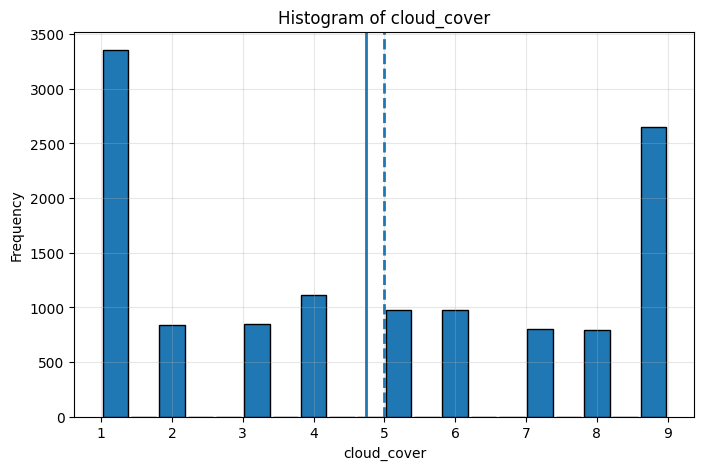

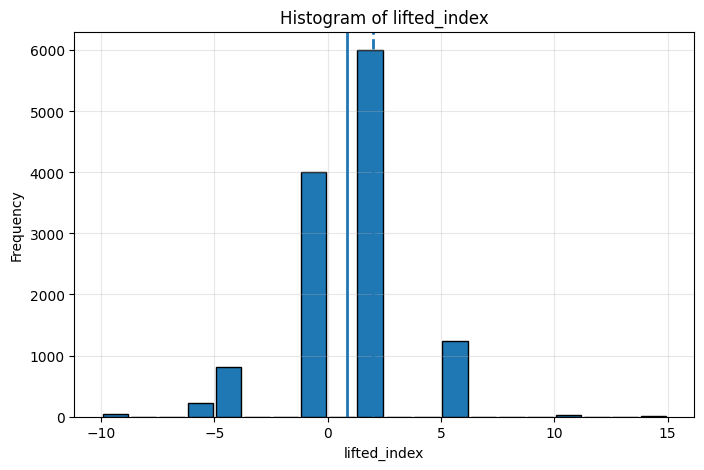

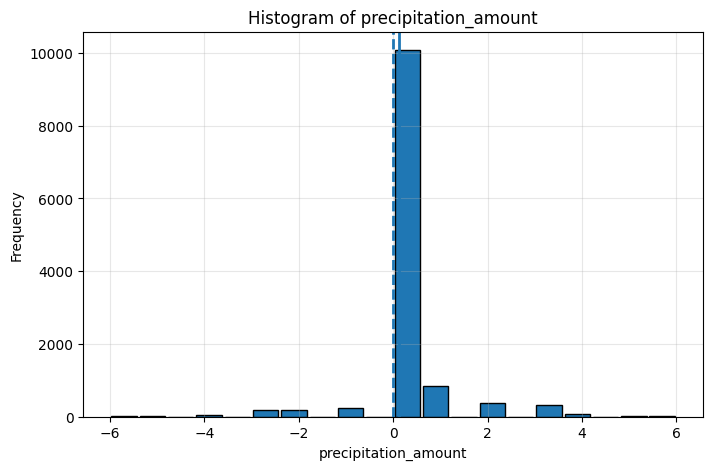

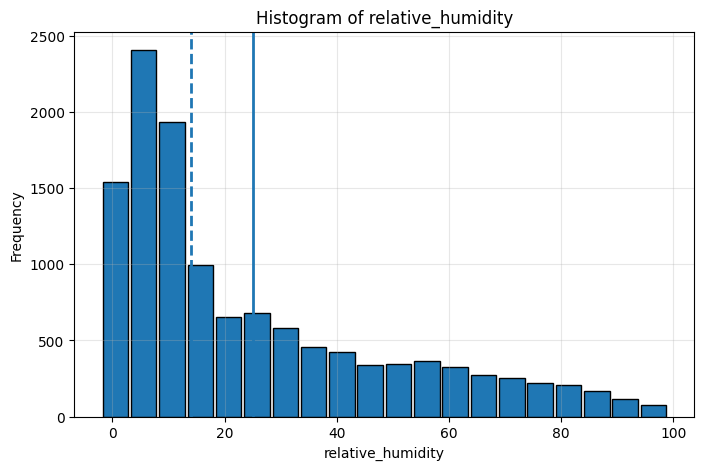

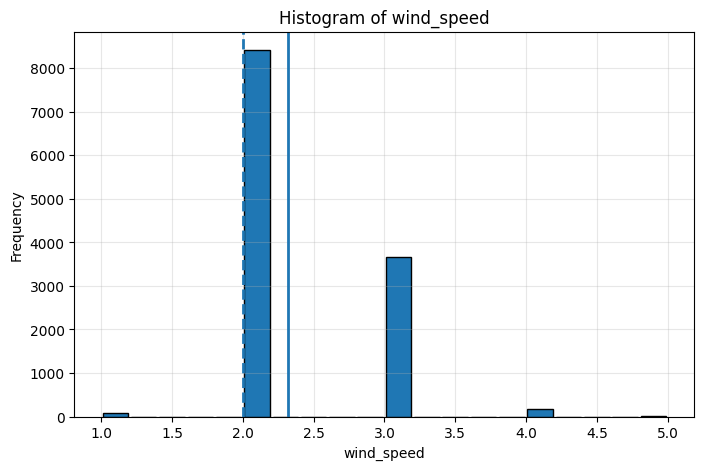

In [ ]:
for column in sensor_columns:

    values = []

    for value in sensor_df[column]:
        values.append(value)

    minimum = min(values)
    maximum = max(values)

    bins = 20

    bin_width = (maximum - minimum) / bins

    frequencies = [0] * bins

    for value in values:

        if value == maximum:
            index = bins - 1
        else:
            index = int((value - minimum) / bin_width)

        frequencies[index] = frequencies[index] + 1

    bin_centers = []

    for i in range(bins):
        center = minimum + (i + 0.5) * bin_width
        bin_centers.append(center)

    plt.figure(figsize=(8, 5))

    plt.bar(
        bin_centers,
        frequencies,
        width=bin_width * 0.9,
        edgecolor='black'
    )
    plt.axvline(
        means[column],
        linewidth=2,
        label='Mean'
    )

    plt.axvline(
        medians[column],
        linewidth=2,
        linestyle='--',
        label='Median'
    )


    plt.title("Histogram of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

Histograms were generated to observe the frequency distribution of each sensor variable
On observing we see that the temperature histogram is negatively skewed, cloud cover is bimodally skewed, lifted index is negatively skewed, precipitation amount is nearly balanced and relative humidity and wind speed are both positively skewed.

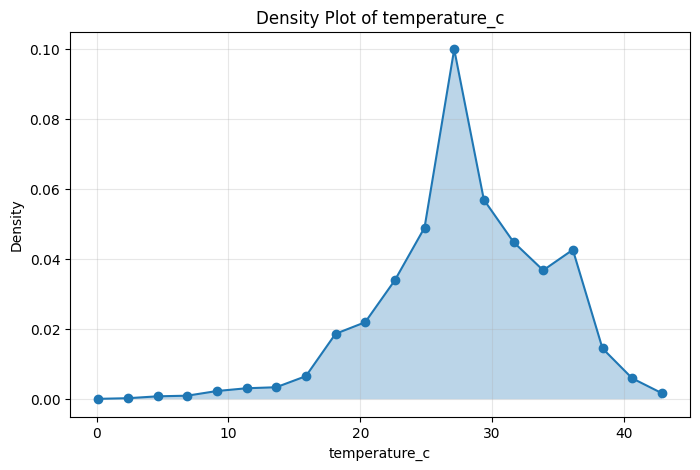

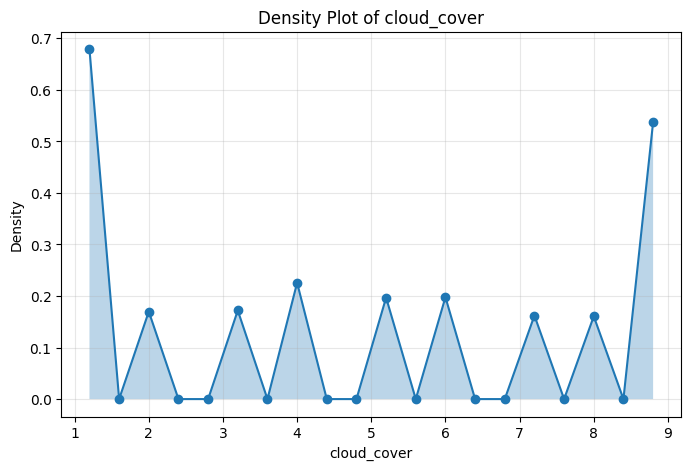

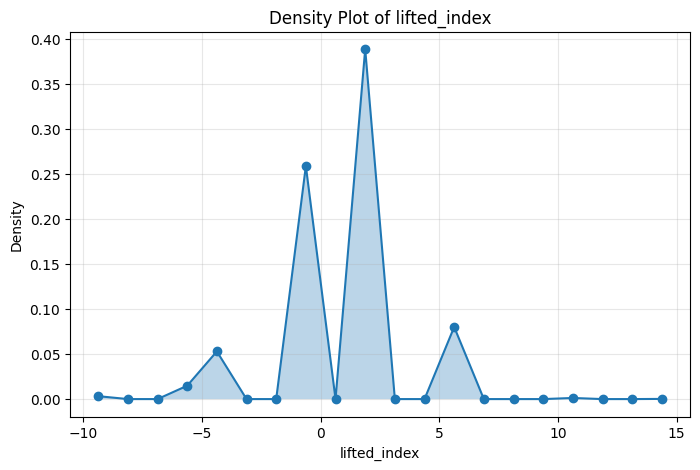

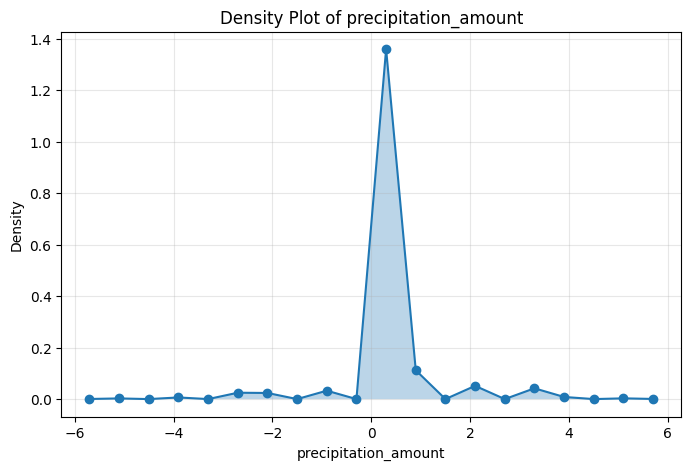

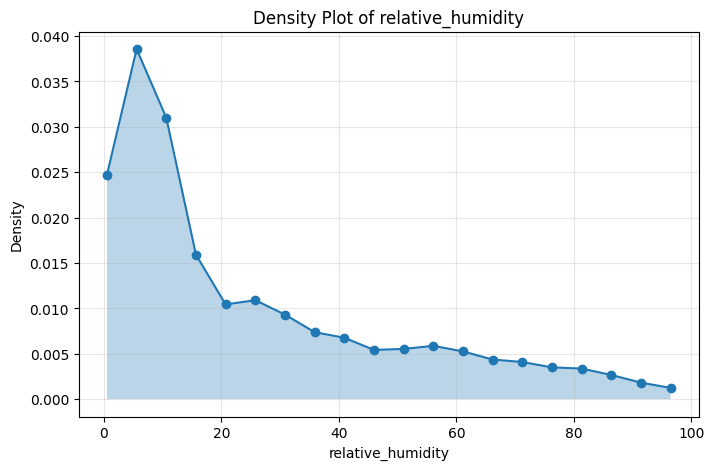

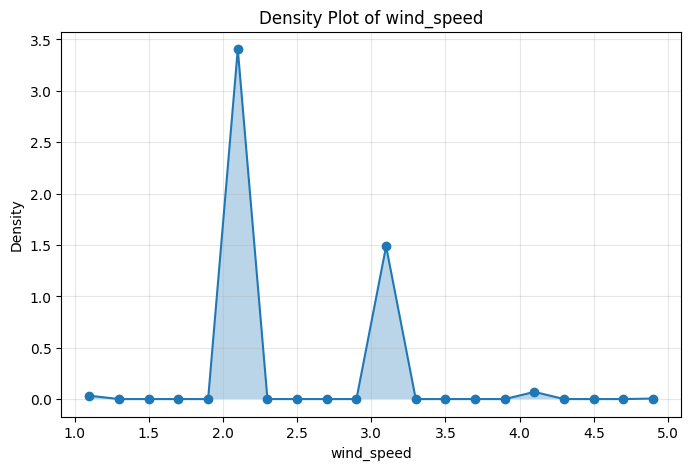

In [ ]:
for column in sensor_columns:

    values = []

    for value in sensor_df[column]:
        values.append(value)

    minimum = min(values)
    maximum = max(values)

    bins = 20

    bin_width = (maximum - minimum) / bins

    frequencies = [0] * bins

    for value in values:

        if value == maximum:
            index = bins - 1

        else:
            index = int((value - minimum) / bin_width)

        frequencies[index] = frequencies[index] + 1

    density = []
    centers = []

    total = len(values)

    for i in range(bins):

        center = minimum + (i + 0.5) * bin_width

        centers.append(center)

        density_value = (
            frequencies[i] /
            (total * bin_width)
        )

        density.append(density_value)

    plt.figure(figsize=(8, 5))

    plt.plot(
        centers,
        density,
        marker='o'
    )

    plt.fill_between(
        centers,
        density,
        alpha=0.3
    )

    plt.title("Density Plot of " + column)
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.grid(alpha=0.3)

    plt.show()

Density plots were generated manually from the frequency distribution. They provide a smoother representation of where sensor observations are concentrated and make it easier to identify the dominant region, spread, and overall shape of each variable.

In [ ]:
Q1_values = {}
Q3_values = {}

for column in sensor_columns:

    values = []

    for value in sensor_df[column]:
        values.append(value)

    values.sort()

    n = len(values)

    middle = n // 2

    if n % 2 == 0:

        lower_half = values[:middle]
        upper_half = values[middle:]

    else:

        lower_half = values[:middle]
        upper_half = values[middle + 1:]

    # Q1

    m = len(lower_half)

    if m % 2 == 1:

        Q1 = lower_half[m // 2]

    else:

        Q1 = (
            lower_half[(m // 2) - 1]
            +
            lower_half[m // 2]
        ) / 2

    # Q3

    m = len(upper_half)

    if m % 2 == 1:

        Q3 = upper_half[m // 2]

    else:

        Q3 = (
            upper_half[(m // 2) - 1]
            +
            upper_half[m // 2]
        ) / 2

    Q1_values[column] = Q1
    Q3_values[column] = Q3

print("Quartiles:")
print()

for column in sensor_columns:

    print(
        column,
        "Q1 =", round(Q1_values[column], 4),
        "Q3 =", round(Q3_values[column], 4)
    )

Quartiles:

temperature_c Q1 = 24.0 Q3 = 32.0
cloud_cover Q1 = 1.0 Q3 = 8.0
lifted_index Q1 = -1.0 Q3 = 2.0
precipitation_amount Q1 = 0.0 Q3 = 0.0
relative_humidity Q1 = 6.0 Q3 = 39.0
wind_speed Q1 = 2.0 Q3 = 3.0


The first and third quartiles were calculated manually to identify the lower and upper portions of each sensor distribution. These quartiles are used to calculate the interquartile range for potential outlier detection.

In [ ]:
outlier_counts = {}

print("POTENTIAL OUTLIERS USING IQR METHOD")
print("=" * 65)

for column in sensor_columns:

    Q1 = Q1_values[column]
    Q3 = Q3_values[column]

    IQR = Q3 - Q1

    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)

    count = 0

    for value in sensor_df[column]:

        if value < lower_limit or value > upper_limit:
            count = count + 1

    outlier_counts[column] = count

    print("\nSensor:", column)
    print("IQR:", round(IQR, 4))
    print("Lower limit:", round(lower_limit, 4))
    print("Upper limit:", round(upper_limit, 4))
    print("Potential outliers:", count)

POTENTIAL OUTLIERS USING IQR METHOD

Sensor: temperature_c
IQR: 8.0
Lower limit: 12.0
Upper limit: 44.0
Potential outliers: 166

Sensor: cloud_cover
IQR: 7.0
Lower limit: -9.5
Upper limit: 18.5
Potential outliers: 0

Sensor: lifted_index
IQR: 3.0
Lower limit: -5.5
Upper limit: 6.5
Potential outliers: 301

Sensor: precipitation_amount
IQR: 0.0
Lower limit: 0.0
Upper limit: 0.0
Potential outliers: 2277

Sensor: relative_humidity
IQR: 33.0
Lower limit: -43.5
Upper limit: 88.5
Potential outliers: 190

Sensor: wind_speed
IQR: 1.0
Lower limit: 0.5
Upper limit: 4.5
Potential outliers: 13


Potential outliers were identified using the IQR method. Observations falling below the lower limit or above the upper limit were considered potential outliers. These observations may represent unusual environmental conditions, sensor noise, or measurement errors and should be investigated before being removed.

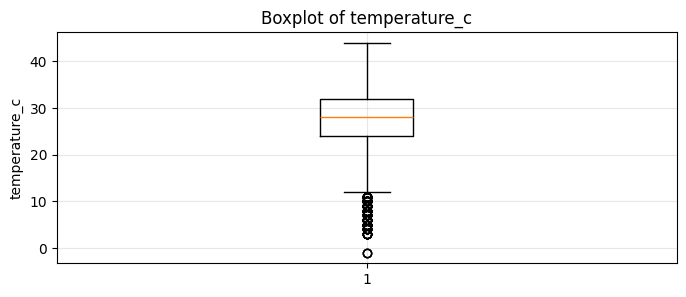

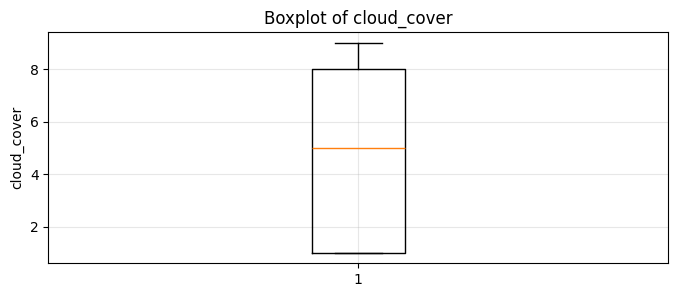

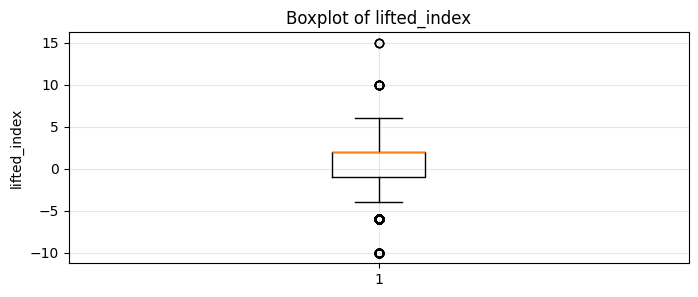

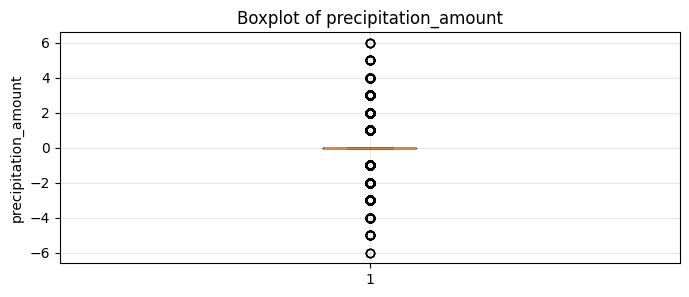

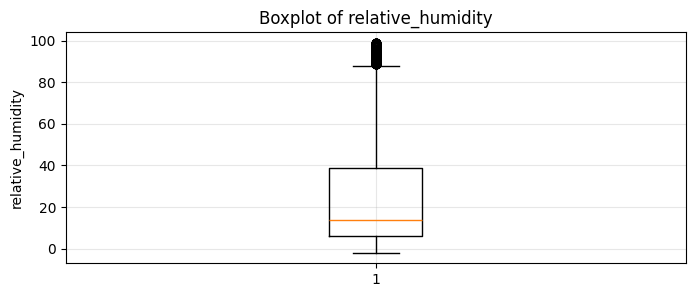

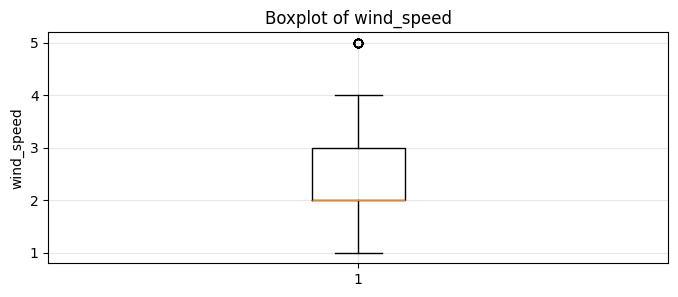

In [ ]:
for column in sensor_columns:

    values = []

    for value in sensor_df[column]:
        values.append(value)

    plt.figure(figsize=(8, 3))

    plt.boxplot(values)

    plt.title("Boxplot of " + column)
    plt.ylabel(column)
    plt.grid(alpha=0.3)

    plt.show()

Boxplots provide a visual representation of the spread of each sensor variable and highlight observations that may be unusually distant from the main data range. These potential outliers require further investigation to determine whether they are valid sensor readings or measurement anomalies.

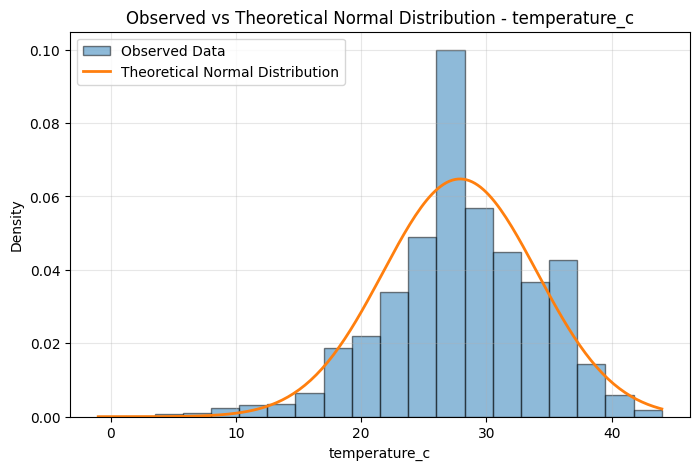

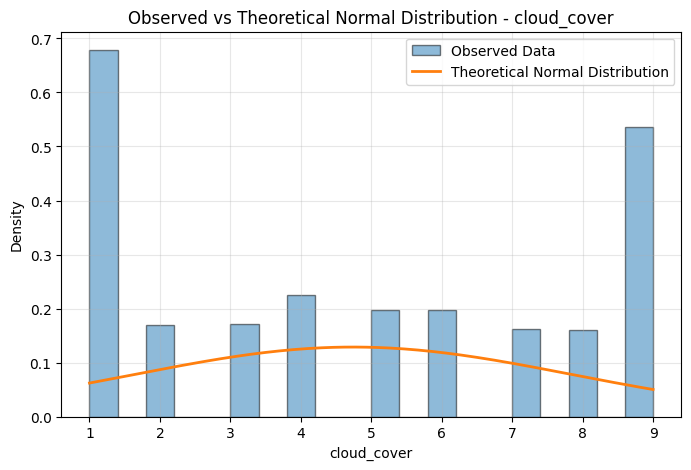

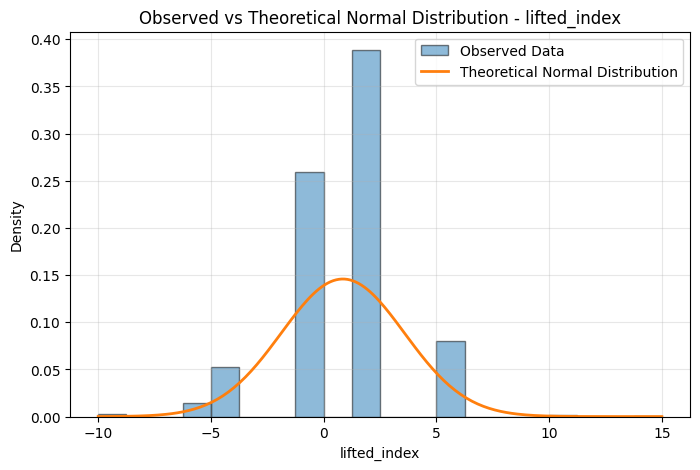

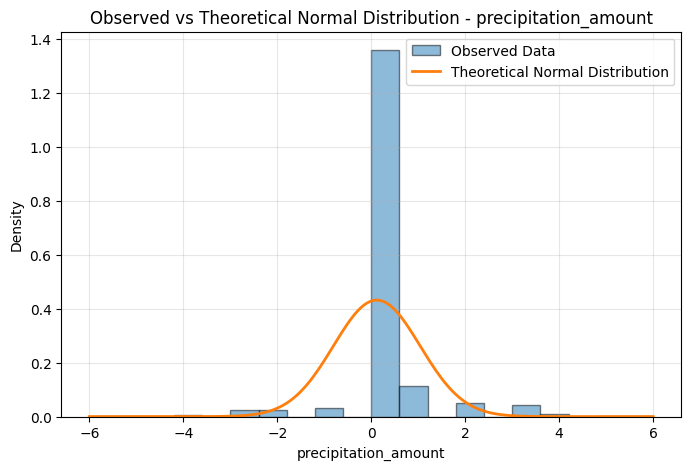

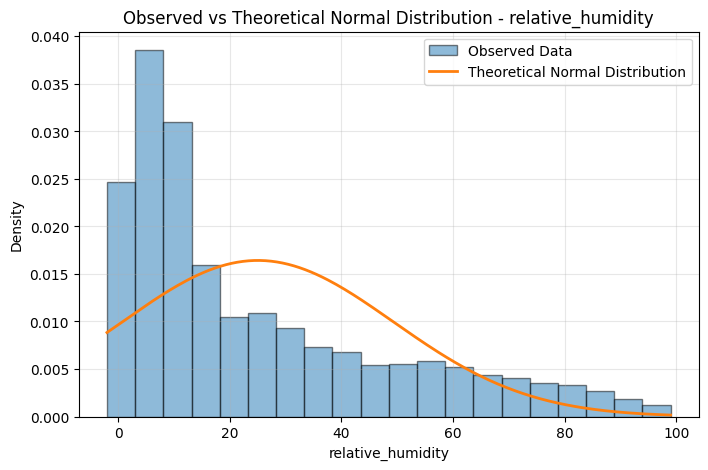

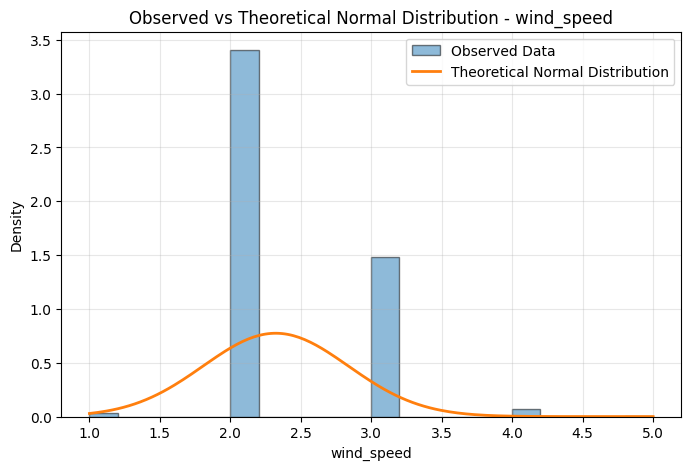

In [ ]:
for column in sensor_columns:

    values = []

    for value in sensor_df[column]:
        values.append(value)

    minimum = min(values)
    maximum = max(values)

    x_values = np.linspace(
        minimum,
        maximum,
        200
    )

    normal_values = []

    mean = means[column]
    std = standard_deviations[column]

    for x in x_values:

        exponent = (
            -0.5 *
            ((x - mean) / std) ** 2
        )

        probability = (
            1 /
            (std * np.sqrt(2 * np.pi))
        ) * np.exp(exponent)

        normal_values.append(probability)

    plt.figure(figsize=(8, 5))

    plt.hist(
        values,
        bins=20,
        density=True,
        alpha=0.5,
        edgecolor='black',
        label='Observed Data'
    )

    plt.plot(
        x_values,
        normal_values,
        linewidth=2,
        label='Theoretical Normal Distribution'
    )

    plt.title(
        "Observed vs Theoretical Normal Distribution - "
        + column
    )

    plt.xlabel(column)
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

The observed distribution of each sensor variable was compared with a theoretical normal distribution having the same mean and standard deviation. A similar bell-shaped pattern suggests approximate normal behavior, whereas substantial differences in shape or tails indicate deviation from normality.

In [ ]:
print("SENSOR DISTRIBUTION INTERPRETATION")
print("=" * 70)

for column in sensor_columns:

    print("\nSensor:", column)
    print("Mean:", round(means[column], 3))
    print("Median:", round(medians[column], 3))
    print(
        "Standard Deviation:",
        round(standard_deviations[column], 3)
    )

    difference = means[column] - medians[column]

    if difference > 0:
        print("Mean is greater than median.")

    elif difference < 0:
        print("Mean is smaller than median.")

    else:
        print("Mean and median are equal.")

    print("Inspect the histogram to determine:")
    print("1. Positive/right skew")
    print("2. Negative/left skew")
    print("3. Approximately symmetric")

SENSOR DISTRIBUTION INTERPRETATION

Sensor: temperature_c
Mean: 27.888
Median: 28.0
Standard Deviation: 6.161
Mean is smaller than median.
Inspect the histogram to determine:
1. Positive/right skew
2. Negative/left skew
3. Approximately symmetric

Sensor: cloud_cover
Mean: 4.743
Median: 5.0
Standard Deviation: 3.1
Mean is smaller than median.
Inspect the histogram to determine:
1. Positive/right skew
2. Negative/left skew
3. Approximately symmetric

Sensor: lifted_index
Mean: 0.851
Median: 2.0
Standard Deviation: 2.736
Mean is smaller than median.
Inspect the histogram to determine:
1. Positive/right skew
2. Negative/left skew
3. Approximately symmetric

Sensor: precipitation_amount
Mean: 0.117
Median: 0.0
Standard Deviation: 0.924
Mean is greater than median.
Inspect the histogram to determine:
1. Positive/right skew
2. Negative/left skew
3. Approximately symmetric

Sensor: relative_humidity
Mean: 25.038
Median: 14.0
Standard Deviation: 24.294
Mean is greater than median.
Inspect the 

Each sensor variable was interpreted using its histogram, mean, median, and standard deviation. The histogram provides the primary evidence for determining the distribution shape, while the relationship between the mean and median provides supporting evidence for the skewness interpretation.

In [ ]:
print("FINAL SENSOR ANALYSIS")
print("=" * 80)

for column in sensor_columns:

    print("\nSensor:", column)

    print(
        "Mean:",
        round(means[column], 3)
    )

    print(
        "Median:",
        round(medians[column], 3)
    )

    print(
        "Standard Deviation:",
        round(standard_deviations[column], 3)
    )

    print(
        "Potential Outliers:",
        outlier_counts[column]
    )

    difference = means[column] - medians[column]

    if difference > 0:
        print(
            "Mean-Median relationship: Mean > Median"
        )

    elif difference < 0:
        print(
            "Mean-Median relationship: Mean < Median"
        )

    else:
        print(
            "Mean-Median relationship: Mean = Median"
        )

    print(
        "Skewness: Infer visually from histogram"
    )

FINAL SENSOR ANALYSIS

Sensor: temperature_c
Mean: 27.888
Median: 28.0
Standard Deviation: 6.161
Potential Outliers: 166
Mean-Median relationship: Mean < Median
Skewness: Infer visually from histogram

Sensor: cloud_cover
Mean: 4.743
Median: 5.0
Standard Deviation: 3.1
Potential Outliers: 0
Mean-Median relationship: Mean < Median
Skewness: Infer visually from histogram

Sensor: lifted_index
Mean: 0.851
Median: 2.0
Standard Deviation: 2.736
Potential Outliers: 301
Mean-Median relationship: Mean < Median
Skewness: Infer visually from histogram

Sensor: precipitation_amount
Mean: 0.117
Median: 0.0
Standard Deviation: 0.924
Potential Outliers: 2277
Mean-Median relationship: Mean > Median
Skewness: Infer visually from histogram

Sensor: relative_humidity
Mean: 25.038
Median: 14.0
Standard Deviation: 24.294
Potential Outliers: 190
Mean-Median relationship: Mean > Median
Skewness: Infer visually from histogram

Sensor: wind_speed
Mean: 2.322
Median: 2.0
Standard Deviation: 0.515
Potential Out

The final analysis summarizes the central tendency, variability, mean-median relationship, and potential outliers for each selected sensor variable. The skewness of each variable is determined visually from its histogram rather than through numerical skewness calculation.